In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
import ast
import seaborn as sns
import matplotlib.pyplot as plt

dataset=load_dataset('lukebarousse/data_jobs')
df=dataset['train'].to_pandas()

df['job_posted_date']=pd.to_datetime(df['job_posted_date'])
df['job_skills']=df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [3]:
df_DA_india=df[(df['job_country']=='India') & (df['job_title_short']=='Data Analyst')]

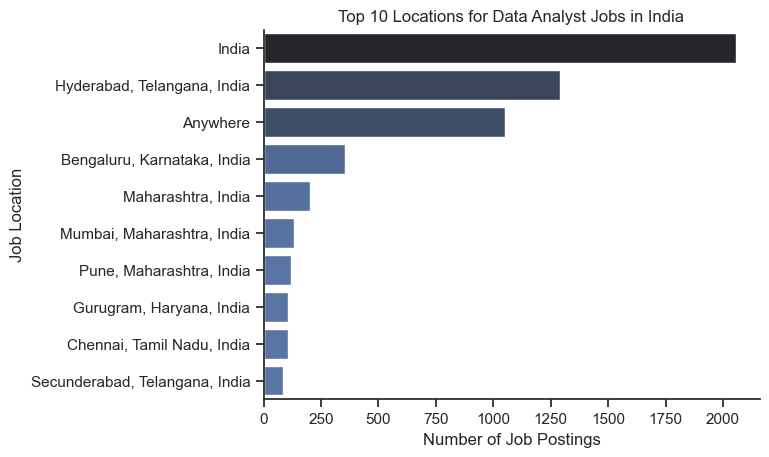

In [21]:
df_plot=df_DA_india['job_location'].value_counts().head(10).to_frame()
sns.set_style("whitegrid")
sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='job_location', hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title('Top 10 Locations for Data Analyst Jobs in India')
plt.xlabel('Number of Job Postings')
plt.ylabel('Job Location')
plt.show()

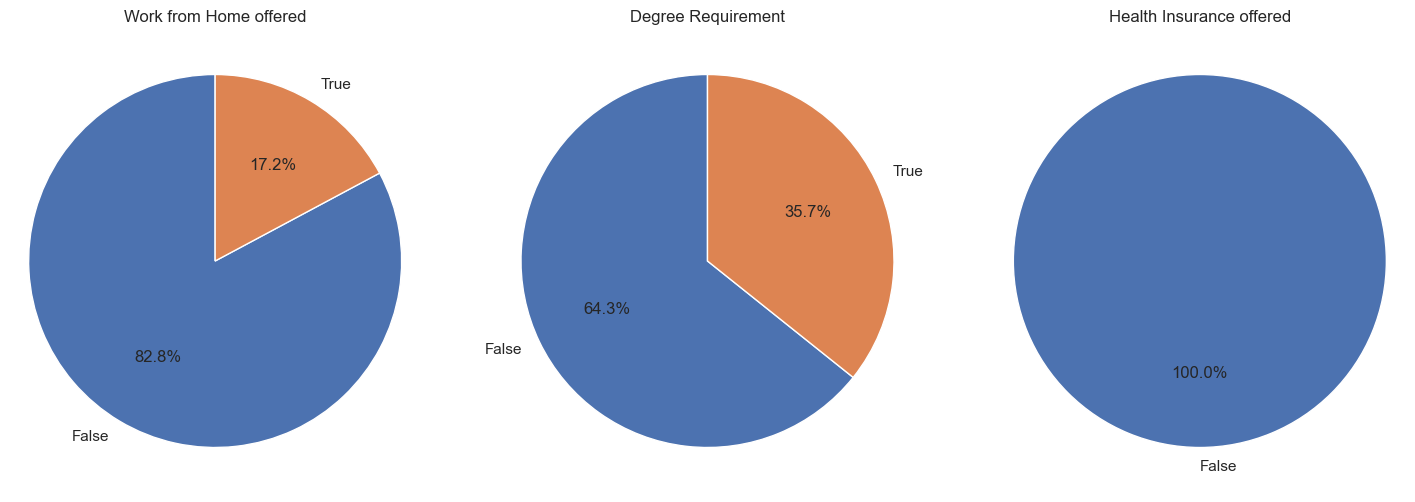

In [30]:
dict_column={
    'job_work_from_home': 'Work from Home offered',
    'job_no_degree_mention': 'Degree Requirement',
    'job_health_insurance': 'Health Insurance offered',
}
fig,ax=plt.subplots(1,3)
fig.set_size_inches(18,6)
for i, (column,title) in enumerate(dict_column.items()):
    value_counts = df_DA_india[column].value_counts()
    labels = [str(label) for label in value_counts.index]
    ax[i].pie(value_counts, labels=labels, autopct='%1.1f%%', startangle=90)
    ax[i].set_title(title)
    ax[i].axis('equal')

plt.show()


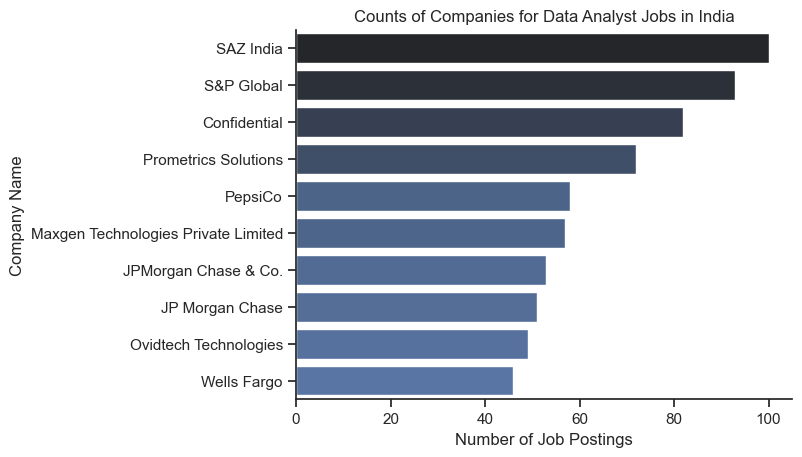

In [31]:
df_plot=df_DA_india['company_name'].value_counts().head(10).to_frame()
sns.set_style("whitegrid")
sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='company_name', hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title('Counts of Companies for Data Analyst Jobs in India')
plt.xlabel('Number of Job Postings')
plt.ylabel('Company Name')
plt.show()